# 19 — Il giudice è imparziale? Confronto fra due giudici di lignaggio diverso

Il G-Eval committato (ambito `test`, notebook 14) è prodotto da un solo giudice,
**gpt-5.4-mini**. `CLAUDE.md` ha sempre rivendicato l'indipendenza del giudice a livello di
*modello* («no self-judging»), mai a livello di **famiglia**: il giudice è un modello OpenAI
della serie GPT-5, e fra i 18 metodi giudicati ce n'è uno — `gpt5mini` — che è anch'esso un
modello OpenAI della serie GPT-5.

I numeri pubblicati rendono la domanda legittima. Fra i quattro LLM l'ordine G-Eval è
**esattamente invertito** rispetto a BERTScore e ROUGE-1 F1:

| | 1º | 2º | 3º | 4º |
|---|---|---|---|---|
| G-Eval (gpt-5.4-mini) | `gpt5mini` 4,89 | `gemma` | `mistral` | `qwen` |
| BERTScore / ROUGE-1 F1 | `mistral` | `qwen` | `gpt5mini` | `gemma` |

`gpt5mini` è **terzo su quattro** sulle metriche ancorate al riferimento e **primo in assoluto**
su G-Eval. Due spiegazioni si adattano al dato altrettanto bene:

- **(a) family bias** — un giudice OpenAI privilegia un generatore OpenAI;
- **(b) nessun bias** — G-Eval misura coerenza/fluenza/pertinenza **rispetto alla fonte**, non
  la sovrapposizione col riferimento, e `gpt5mini` può semplicemente scrivere in prosa migliore
  pur aderendo meno al riferimento.

**Un giudice solo non può separarle.** Un giudice di lignaggio diverso sì.

## Disegno dell'esperimento

Confronto **appaiato sullo stesso testo**: si rigiudicano riassunti *già generati e già
giudicati*, così l'unica variabile che cambia è il giudice e qualunque differenza sistematica
è attribuibile a lui.

| | |
|---|---|
| Giudice A (committato) | `gpt-5.4-mini` — OpenAI, stessa famiglia di `gpt5mini` |
| Giudice B (questo notebook) | `DeepSeek-V3.2-Speciale` — lignaggio completamente diverso |
| Metodi | 4 LLM (dove il bias si vedrebbe) + **3 controlli non-LLM** presi a quote diverse della graduatoria |
| Righe | campione casuale con seed, così una corsa parziale resta un campione non distorto |
| Prompt | **identico**: stessi messaggi, stesse rubriche, stesso `response_format` |

I tre controlli sono la parte che fa funzionare il disegno: separano un effetto generico
«al giudice piace la prosa LLM» da un effetto **specifico della famiglia OpenAI**. Se il
secondo giudice penalizzasse `gpt5mini` e lasciasse stare gli altri LLM, sarebbe family bias;
se muovesse tutti gli LLM allo stesso modo rispetto ai controlli, sarebbe preferenza per la
prosa LLM — un effetto reale ma condiviso dai due giudici, e quindi non una distorsione del
confronto.

Il notebook **non genera nulla e non spende nulla**: legge le due cache di giudizi già
prodotte. La corsa che ha prodotto quella del giudice B è
[`scripts/pilota_giudice_deepseek.py`](../scripts/pilota_giudice_deepseek.py).

> **Nota di ambito.** Questo notebook valida il *giudice*, non aggiunge una metrica. I numeri
> G-Eval del benchmark restano quelli di gpt-5.4-mini: qui si stabilisce solo se ci si può
> fidare.

In [1]:
# --- Configurazione ---------------------------------------------------------
import json
from pathlib import Path

import numpy as np
import pandas as pd
import summ_utils as su

BASE = su.trova_base_dir()
P = su.percorsi_standard(BASE)

SCOPE = 'test'
CACHE_A = P['metrics_dir'] / f'geval_cache_{SCOPE}.jsonl'             # giudice committato
CACHE_B = P['metrics_dir'] / f'geval_cache_{SCOPE}_deepseek.jsonl'    # secondo giudice
OUT = P['metrics_dir'] / f'confronto_giudici_{SCOPE}.json'

GIUDICE_A = 'gpt-5.4-mini'
GIUDICE_B = 'DeepSeek-V3.2-Speciale'

# 4 LLM + 3 controlli non-LLM: i controlli separano "al giudice piace la prosa LLM"
# da "al giudice piace la SUA famiglia". Stessa lista dello script del pilota.
METODI_LLM = ['gpt5mini', 'gemma', 'qwen', 'mistral']
METODI_CONTROLLO = ['primera', 'firstk_psr', 'lexrank']
METODI = METODI_LLM + METODI_CONTROLLO

# DeepSeek e' un deployment MaaS: nessuna prompt cache, input a tariffa piena
# (EUR/1M token, listino Azure in EUR — la valuta NON e' cosmetica, cfr. CLAUDE.md).
PREZZI_B = {'input': 0.50, 'cached': 0.50, 'output': 1.60}

# Durata misurata della corsa pilota: dalla creazione della cache (2026-09-17 14:32:32)
# all'ultima scrittura (2026-09-18 08:32:06). Non e' deducibile dalla cache, che non
# porta timestamp per riga, quindi e' l'unica costante misurata a mano qui.
ORE_PILOTA = 17.99
RPM_NOMINALE = 20            # SKU GlobalStandard del deployment 'deepseek-giudice'

# Stessa palette del notebook 05/18: l'identita' visiva di un metodo non cambia.
COLORI = {'firstk_psr': '#5f6b7a', 'lexrank': '#1baf7a', 'primera': '#8250df',
          'qwen': '#d6336c', 'gemma': '#15aabf', 'mistral': '#846358',
          'gpt5mini': '#e8590c'}
INK, INK2, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
COL_A, COL_B = '#e8590c', '#2a78d6'

print(f"Giudice A : {GIUDICE_A}  <- {CACHE_A.name}")
print(f"Giudice B : {GIUDICE_B}  <- {CACHE_B.name}")

Giudice A : gpt-5.4-mini  <- geval_cache_test.jsonl
Giudice B : DeepSeek-V3.2-Speciale  <- geval_cache_test_deepseek.jsonl


## Caricamento

Da ciascuna cache si prendono i soli giudizi **riusciti** (`errore is None`: il filtro
contenuti di Azure e i fallimenti di parsing lasciano righe scoperte in entrambe) e si tiene
l'intersezione per coppia `(metodo, row_id)` — solo le righe che **entrambi** i giudici hanno
valutato entrano nel confronto. È questo che rende il test appaiato: ogni delta è calcolato
sullo stesso identico testo.

In [2]:
def carica(percorso, metodi):
    """{metodo: {row_id: {colonne geval}}} dei soli giudizi riusciti."""
    cache = su.CacheGiudizi(percorso)
    dati = {m: cache.per_metodo(m) for m in metodi}
    totali = cache.totali_token()
    cache.chiudi()
    return dati, totali


giudizi_a, token_a = carica(CACHE_A, METODI)
giudizi_b, token_b = carica(CACHE_B, METODI)

# Tabella appaiata: una riga per (metodo, row_id) giudicata da entrambi.
righe = []
for m in METODI:
    a, b = giudizi_a[m], giudizi_b[m]
    for rid in sorted(set(a) & set(b)):
        righe.append({'metodo': m, 'row_id': rid,
                      'famiglia': 'LLM' if m in METODI_LLM else 'controllo',
                      **{f'a_{c}': a[rid][c] for c in su.COLONNE_METRICHE_GEVAL},
                      **{f'b_{c}': b[rid][c] for c in su.COLONNE_METRICHE_GEVAL}})
appaiati = pd.DataFrame(righe)
appaiati['delta'] = appaiati['b_geval_media'] - appaiati['a_geval_media']

righe_comuni = sorted(set(appaiati['row_id']))
print(f'Giudizi appaiati : {len(appaiati):,} su {len(righe_comuni):,} cluster distinti')
print(f'Metodi           : {appaiati["metodo"].nunique()} '
      f'({len(METODI_LLM)} LLM + {len(METODI_CONTROLLO)} controlli)')
print(f'Copertura per metodo: {appaiati.groupby("metodo").size().min():,} - '
      f'{appaiati.groupby("metodo").size().max():,} righe')

Giudizi appaiati : 6,577 su 950 cluster distinti
Metodi           : 7 (4 LLM + 3 controlli)
Copertura per metodo: 931 - 950 righe


## Vista 1 — I due giudici, metodo per metodo

`delta = B − A`: positivo se il secondo giudice è **più generoso** del primo su quel metodo.

In [3]:
def ic95(valori):
    """Media e intervallo di confidenza al 95% (approssimazione normale, campioni > 900)."""
    a = np.asarray(valori, dtype=np.float64)
    media = a.mean()
    se = a.std(ddof=1) / np.sqrt(a.size)
    return media, media - 1.96 * se, media + 1.96 * se, se


per_metodo = {}
for m in METODI:
    sub = appaiati[appaiati['metodo'] == m]
    media_d, lo, hi, se = ic95(sub['delta'])
    per_metodo[m] = {
        'n': int(len(sub)),
        'famiglia': 'LLM' if m in METODI_LLM else 'controllo',
        GIUDICE_A: round(float(sub['a_geval_media'].mean()), 3),
        GIUDICE_B: round(float(sub['b_geval_media'].mean()), 3),
        'delta': round(float(media_d), 3),
        'ic95_basso': round(float(lo), 3), 'ic95_alto': round(float(hi), 3),
    }

tabella = pd.DataFrame(per_metodo).T
tabella = tabella.sort_values(GIUDICE_B, ascending=False)
display(tabella[['n', 'famiglia', GIUDICE_A, GIUDICE_B, 'delta', 'ic95_basso', 'ic95_alto']])

,n,famiglia,gpt-5.4-mini,DeepSeek-V3.2-Speciale,delta,ic95_basso,ic95_alto
gpt5mini,950,LLM,4.876,4.919,0.044,0.024,0.064
gemma,948,LLM,4.776,4.85,0.075,0.047,0.103
mistral,938,LLM,4.708,4.585,-0.123,-0.162,-0.084
qwen,942,LLM,4.537,4.551,0.014,-0.027,0.055
primera,935,controllo,4.273,4.01,-0.263,-0.315,-0.21
firstk_psr,933,controllo,2.834,2.539,-0.295,-0.363,-0.227
lexrank,931,controllo,2.151,1.879,-0.272,-0.32,-0.224


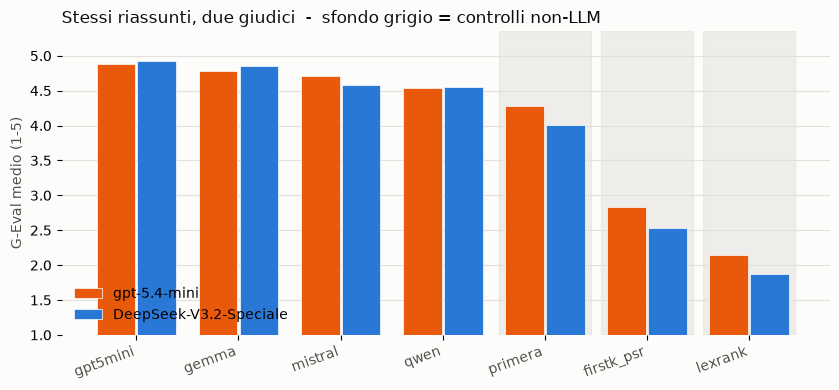

In [4]:
import matplotlib.pyplot as plt

ordine = list(tabella.index)
x = np.arange(len(ordine))
fig, ax = plt.subplots(figsize=(8.5, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(x - 0.2, [per_metodo[m][GIUDICE_A] for m in ordine], 0.38, label=GIUDICE_A,
       color=COL_A, edgecolor='white', lw=0.5, zorder=2)
ax.bar(x + 0.2, [per_metodo[m][GIUDICE_B] for m in ordine], 0.38, label=GIUDICE_B,
       color=COL_B, edgecolor='white', lw=0.5, zorder=2)
for i, m in enumerate(ordine):
    if per_metodo[m]['famiglia'] == 'controllo':
        ax.axvspan(i - 0.45, i + 0.45, color=GRID, alpha=0.5, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(ordine, rotation=20, ha='right', color=INK2)
ax.set_ylim(1, 5.35)
ax.set_ylabel('G-Eval medio (1-5)', color=INK2)
ax.set_title('Stessi riassunti, due giudici  -  sfondo grigio = controlli non-LLM',
             color=INK, loc='left')
ax.grid(axis='y', color=GRID, lw=0.8, zorder=0)
ax.legend(frameon=False, loc='lower left')
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

## Vista 2 — Il test del family bias

Il delta grezzo di `gpt5mini` non basta: se il secondo giudice fosse semplicemente più severo
(o più generoso) con **tutti**, ogni metodo avrebbe un delta negativo (o positivo) e non
direbbe nulla sulla famiglia. Quello che conta è il **contrasto**:

$$\text{contrasto} = \delta_{\texttt{gpt5mini}} - \overline{\delta}_{\text{altri LLM}}$$

calcolato **riga per riga** sui soli cluster in cui tutti e quattro gli LLM sono stati
giudicati da entrambi — quindi appaiato anche rispetto alla difficoltà del cluster.

**Il test è direzionale, e conviene fissarne il segno prima di guardare il risultato.** Se il
giudice A gonfiasse `gpt5mini` perché è di casa, il giudice B gli toglierebbe qualcosa che agli
altri LLM non toglie: `delta` di `gpt5mini` più negativo degli altri, quindi **contrasto
negativo**. Le tre letture possibili sono dunque:

| contrasto | lettura |
|---|---|
| **negativo**, IC95% sotto lo zero | il giudice A favoriva la propria famiglia: **family bias confermato** |
| compatibile con zero | nessuna distorsione di famiglia rilevabile |
| **positivo**, IC95% sopra lo zero | direzione **opposta** al bias: con un giudice estraneo `gpt5mini` guadagna, non perde |

Da tenere presente leggendo il risultato: con ~940 cluster appaiati l'errore standard è così
piccolo che **un effetto irrilevante può risultare statisticamente distinguibile da zero**.
La domanda «è diverso da zero?» e la domanda «è abbastanza grande da cambiare la graduatoria?»
vanno tenute separate — la seconda si risponde confrontando il contrasto con i distacchi reali
fra i metodi, che è quello che fa la cella qui sotto.

In [5]:
# Pivot riga x metodo sui delta, ristretto ai cluster con tutti e 4 gli LLM.
pivot = appaiati.pivot(index='row_id', columns='metodo', values='delta')
completi = pivot.dropna(subset=METODI_LLM)
altri_llm = [m for m in METODI_LLM if m != 'gpt5mini']
contrasto = completi['gpt5mini'] - completi[altri_llm].mean(axis=1)

media_c, lo_c, hi_c, se_c = ic95(contrasto)
print(f'Cluster con tutti e 4 gli LLM giudicati da entrambi: {len(completi):,}\n')
print(f'  delta gpt5mini          : {completi["gpt5mini"].mean():+.3f}')
for m in altri_llm:
    print(f'  delta {m:<18}: {completi[m].mean():+.3f}')
print(f'\n  CONTRASTO               : {media_c:+.3f}   IC95% [{lo_c:+.3f}, {hi_c:+.3f}]')

# Test DIREZIONALE: il family bias predice un contrasto NEGATIVO (vedi sopra).
zero_dentro = lo_c <= 0 <= hi_c
bias_confermato = hi_c < 0
if bias_confermato:
    esito = 'FAMILY BIAS CONFERMATO: il giudice A favoriva la propria famiglia'
elif zero_dentro:
    esito = 'nessuna distorsione di famiglia rilevabile (contrasto compatibile con zero)'
else:
    esito = ('FAMILY BIAS ESCLUSO, e nella direzione OPPOSTA: con un giudice estraneo '
             'gpt5mini guadagna rispetto agli altri LLM, non perde')
print(f'\n  -> {esito}')
print(f'  effetto minimo rilevabile (80% di potenza): {2.8 * se_c:.3f} punti G-Eval')

# Rilevanza pratica: il contrasto va commisurato ai distacchi reali fra i metodi,
# non solo allo zero. Con ~940 cluster l'IC e' strettissimo e quasi tutto "conta".
medie_llm = {m: appaiati.loc[appaiati['metodo'] == m, 'a_geval_media'].mean()
             for m in METODI_LLM}
distacco = medie_llm['gpt5mini'] - max(v for m, v in medie_llm.items() if m != 'gpt5mini')
print(f'\n  Rilevanza pratica:')
print(f'    distacco gpt5mini sul 2o LLM (giudice A): {distacco:+.3f} punti')
print(f'    contrasto misurato                     : {media_c:+.3f} punti '
      f'({abs(media_c) / distacco:.0%} del distacco, con segno '
      f'{"favorevole" if media_c > 0 else "sfavorevole"} a gpt5mini)')
print(f'    -> il primato di gpt5mini su G-Eval non e\' spiegabile con la parentela '
      f'col giudice')

Cluster con tutti e 4 gli LLM giudicati da entrambi: 938

  delta gpt5mini          : +0.041
  delta gemma             : +0.075
  delta qwen              : +0.019
  delta mistral           : -0.123

  CONTRASTO               : +0.051   IC95% [+0.024, +0.078]

  -> FAMILY BIAS ESCLUSO, e nella direzione OPPOSTA: con un giudice estraneo gpt5mini guadagna rispetto agli altri LLM, non perde
  effetto minimo rilevabile (80% di potenza): 0.039 punti G-Eval

  Rilevanza pratica:
    distacco gpt5mini sul 2o LLM (giudice A): +0.100 punti
    contrasto misurato                     : +0.051 punti (51% del distacco, con segno favorevole a gpt5mini)
    -> il primato di gpt5mini su G-Eval non e' spiegabile con la parentela col giudice


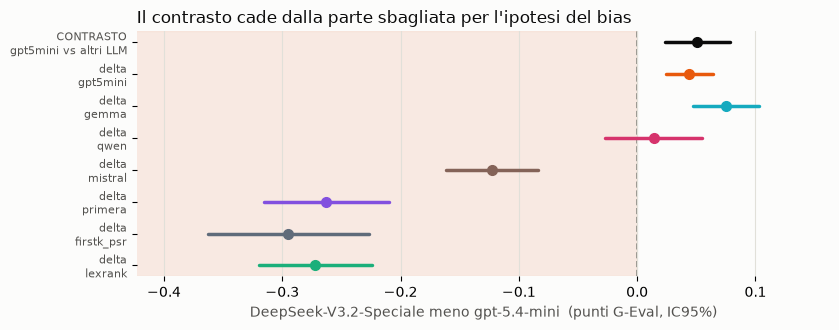

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
etichette = ['CONTRASTO\ngpt5mini vs altri LLM'] + [f'delta\n{m}' for m in METODI]
valori = [(media_c, lo_c, hi_c)] + [
    (per_metodo[m]['delta'], per_metodo[m]['ic95_basso'], per_metodo[m]['ic95_alto'])
    for m in METODI]
colori = [INK] + [COLORI[m] for m in METODI]
for i, ((v, lo, hi), c) in enumerate(zip(valori, colori)):
    ax.plot([lo, hi], [i, i], color=c, lw=2.5, solid_capstyle='round', zorder=2)
    ax.plot([v], [i], 'o', color=c, ms=7, zorder=3)
ax.axvline(0, color=MUTED, lw=1.2, ls='--', zorder=1)
ax.set_yticks(range(len(etichette)))
ax.set_yticklabels(etichette, fontsize=8, color=INK2)
ax.invert_yaxis()
ax.set_xlabel(f'{GIUDICE_B} meno {GIUDICE_A}  (punti G-Eval, IC95%)', color=INK2)
# La zona a sinistra dello zero e' quella che il family bias prevedeva.
ax.axvspan(-1, 0, color='#f4d3c4', alpha=0.45, zorder=0)
ax.annotate('zona prevista dal family bias', xy=(0, len(etichette) - 0.4),
            xytext=(-4, 0), textcoords='offset points', ha='right', va='center',
            fontsize=7.5, color=MUTED)
ax.set_xlim(min(v[1] for v in valori) - 0.06, max(v[2] for v in valori) + 0.06)
ax.set_title('Il contrasto cade dalla parte sbagliata per l\'ipotesi del bias',
             color=INK, loc='left')
ax.grid(axis='x', color=GRID, lw=0.8, zorder=0)
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

## Vista 3 — L'ordinamento sopravvive al cambio di giudice?

È la domanda che conta davvero per il benchmark. Un giudice può essere sistematicamente più
severo senza fare alcun danno, purché **ordini i metodi allo stesso modo**: le conclusioni del
notebook 05 sono affermazioni di ordine, non di livello assoluto.

In [7]:
def rho_spearman(x, y):
    """Correlazione di rango, senza dipendere da scipy (nessun pareggio qui)."""
    rx = pd.Series(x).rank().to_numpy()
    ry = pd.Series(y).rank().to_numpy()
    return float(np.corrcoef(rx, ry)[0, 1])


rank_a = tabella.sort_values(GIUDICE_A, ascending=False).index.tolist()
rank_b = tabella.sort_values(GIUDICE_B, ascending=False).index.tolist()
rho = rho_spearman(tabella[GIUDICE_A].astype(float), tabella[GIUDICE_B].astype(float))

print(f'ordine {GIUDICE_A:<22}: {" > ".join(rank_a)}')
print(f'ordine {GIUDICE_B:<22}: {" > ".join(rank_b)}')
print(f'\nrho di Spearman sulle medie per metodo: {rho:.3f}')
print('inversioni:', 'NESSUNA' if rank_a == rank_b
      else [m for m, n in zip(rank_a, rank_b) if m != n])

ordine gpt-5.4-mini          : gpt5mini > gemma > mistral > qwen > primera > firstk_psr > lexrank
ordine DeepSeek-V3.2-Speciale: gpt5mini > gemma > mistral > qwen > primera > firstk_psr > lexrank

rho di Spearman sulle medie per metodo: 1.000
inversioni: NESSUNA


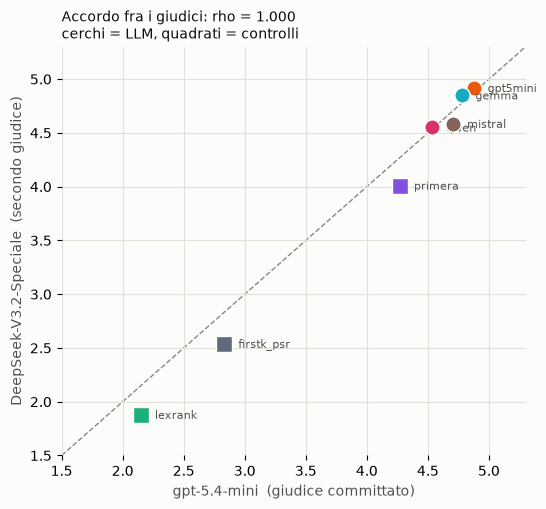

In [8]:
fig, ax = plt.subplots(figsize=(5.6, 5.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
lim = (1.5, 5.3)
ax.plot(lim, lim, color=MUTED, lw=1, ls='--', zorder=1)
for m in METODI:
    marcatore = 'o' if per_metodo[m]['famiglia'] == 'LLM' else 's'
    ax.plot(per_metodo[m][GIUDICE_A], per_metodo[m][GIUDICE_B], marcatore,
            color=COLORI[m], ms=11, zorder=3, mec='white', mew=1)
    ax.annotate(m, (per_metodo[m][GIUDICE_A], per_metodo[m][GIUDICE_B]),
                textcoords='offset points', xytext=(10, -3), fontsize=8, color=INK2)
ax.set_xlim(*lim)
ax.set_ylim(*lim)
ax.set_xlabel(f'{GIUDICE_A}  (giudice committato)', color=INK2)
ax.set_ylabel(f'{GIUDICE_B}  (secondo giudice)', color=INK2)
ax.set_title(f'Accordo fra i giudici: rho = {rho:.3f}\ncerchi = LLM, quadrati = controlli',
             color=INK, loc='left', fontsize=10)
ax.grid(color=GRID, lw=0.8, zorder=0)
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

## Vista 4 — Dove i due giudici divergono davvero

Il contrasto esclude un effetto **di famiglia**, ma non dice che i due giudici siano d'accordo
su tutto — e infatti non lo sono. Qui si guarda dove il disaccordo si concentra davvero: nel
confronto fra LLM e controlli non-LLM, e fra le quattro dimensioni della rubrica.

In [9]:
gruppi = appaiati.groupby('famiglia')['delta']
riepilogo = pd.DataFrame({
    'n': gruppi.size(),
    'delta medio': gruppi.mean().round(3),
    'ds': gruppi.std().round(3),
}).loc[['LLM', 'controllo']]
display(riepilogo)

d_llm, d_ctrl = riepilogo.loc['LLM', 'delta medio'], riepilogo.loc['controllo', 'delta medio']
print(f'Divario LLM - controlli nel delta: {d_llm - d_ctrl:+.3f} punti')
print(f'  {GIUDICE_B} allarga il distacco fra prosa LLM e prosa estrattiva'
      if d_llm > d_ctrl else f'  {GIUDICE_B} riduce il distacco')

print('\nPer dimensione della rubrica (delta medio B - A):')
per_dim = {}
for dim in su.DIMENSIONI_GEVAL:
    col = f'geval_{dim}'
    d_all = appaiati[f'b_{col}'] - appaiati[f'a_{col}']
    per_dim[dim] = {
        'tutti': round(float(d_all.mean()), 3),
        'LLM': round(float(d_all[appaiati['famiglia'] == 'LLM'].mean()), 3),
        'controlli': round(float(d_all[appaiati['famiglia'] == 'controllo'].mean()), 3),
    }
display(pd.DataFrame(per_dim).T)

,n,delta medio,ds
famiglia,,,
LLM,3778,0.003,0.522
controllo,2799,-0.277,0.884


Divario LLM - controlli nel delta: +0.280 punti
  DeepSeek-V3.2-Speciale allarga il distacco fra prosa LLM e prosa estrattiva

Per dimensione della rubrica (delta medio B - A):


,tutti,LLM,controlli
coherence,-0.321,-0.193,-0.493
consistency,0.185,0.248,0.101
fluency,-0.032,-0.026,-0.040
relevance,-0.297,-0.017,-0.675


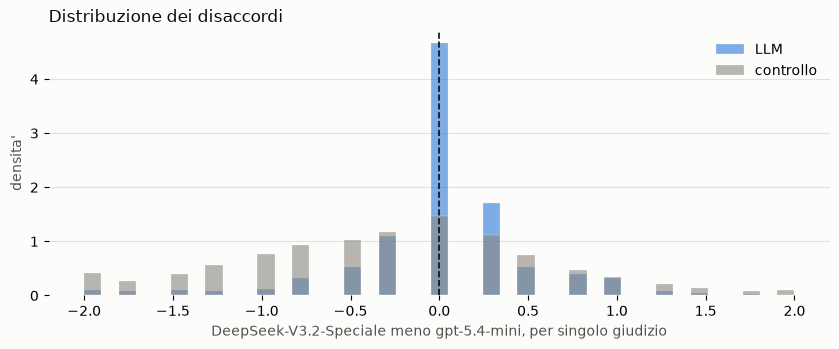

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 3.6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for etichetta, colore in (('LLM', COL_B), ('controllo', MUTED)):
    d = appaiati.loc[appaiati['famiglia'] == etichetta, 'delta']
    ax.hist(np.clip(d, -2, 2), bins=41, alpha=0.6, color=colore, label=etichetta,
            edgecolor='white', lw=0.3, zorder=2, density=True)
ax.axvline(0, color=INK, lw=1.2, ls='--', zorder=3)
ax.set_xlabel(f'{GIUDICE_B} meno {GIUDICE_A}, per singolo giudizio', color=INK2)
ax.set_ylabel('densita\'', color=INK2)
ax.set_title('Distribuzione dei disaccordi', color=INK, loc='left')
ax.grid(axis='y', color=GRID, lw=0.8, zorder=0)
ax.legend(frameon=False)
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

## Vista 5 — Perché il secondo giudice resta un pilota e non diventa la metrica

La domanda naturale, una volta stabilito che il secondo giudice è utilizzabile, è: perché non
rifare con lui tutto il benchmark? La risposta non è la qualità ma la **portata** del
deployment, e si estrapola dalla durata misurata del pilota.

In [11]:
costo_b = sum(su.costo_da_token(token_b, PREZZI_B).values())
n_b = token_b['n_giudizi']
per_giudizio = costo_b / n_b
ritmo = n_b / ORE_PILOTA          # giudizi/h effettivi

print(f'Pilota {GIUDICE_B}:')
print(f'  giudizi            : {n_b:,}')
print(f'  input              : {token_b["prompt_tokens"] / n_b:,.0f} token/giudizio '
      f'({token_b["cached_tokens"] / max(token_b["prompt_tokens"], 1):.0%} in cache)')
print(f'  output             : {token_b["completion_tokens"] / n_b:,.1f} token/giudizio')
print(f'  costo              : EUR {costo_b:.2f}  (EUR {per_giudizio:.5f}/giudizio)')
print(f'  durata             : {ORE_PILOTA:.2f} h  ->  {ritmo:,.0f} giudizi/h '
      f'({ritmo / 60:.2f}/min)')
print(f'  resa sulla quota   : {ritmo / 60 / RPM_NOMINALE:.0%} dei {RPM_NOMINALE} RPM nominali '
      f'(il resto e\' attesa di backoff sui 429)')

# Dimensione reale dei due ambiti: per 'test' la si conta dalla cache del giudice A,
# che quell'ambito lo ha coperto per intero.
n_test = token_a['n_giudizi']
print(f'\nEstrapolazione a tutto il benchmark ({n_test:,} giudizi per ambito):')
print(f'  {"ambito":<22}{"giudizi":>10}{"durata":>12}{"costo":>12}')
for etichetta, tot in (('solo test', n_test), ('test + test_budgetref', 2 * n_test)):
    ore = tot / ritmo
    print(f'  {etichetta:<22}{tot:>10,}{ore / 24:>9.1f} gg{"EUR " + f"{tot * per_giudizio:.2f}":>12}')

Pilota DeepSeek-V3.2-Speciale:
  giudizi            : 6,997
  input              : 2,511 token/giudizio (0% in cache)
  output             : 33.9 token/giudizio
  costo              : EUR 9.16  (EUR 0.00131/giudizio)
  durata             : 17.99 h  ->  389 giudizi/h (6.48/min)
  resa sulla quota   : 32% dei 20 RPM nominali (il resto e' attesa di backoff sui 429)

Estrapolazione a tutto il benchmark (100,621 giudizi per ambito):
  ambito                   giudizi      durata       costo
  solo test                100,621     10.8 gg  EUR 131.78
  test + test_budgetref    201,242     21.6 gg  EUR 263.57


Per confronto, `gpt-5.4-mini` ha coperto l'intero ambito `test` in **3–12 h** a seconda del
numero di thread (cfr. `CLAUDE.md`): è 20–80× più veloce **ed è anche più economico per
giudizio**, nonostante un listino per token più alto, perché il suo deployment GlobalStandard
ha la **prompt cache** — che un deployment MaaS non offre. La sorgente troncata condivisa fra i
metodi di una riga, che è il motivo per cui l'ordine dei messaggi è un contratto nel notebook
14, con DeepSeek si ripaga per intero a ogni chiamata.

Il vincolo quindi non è il denaro ma la **quota**: 20 RPM nominali, ~6,5 giudizi/min effettivi.
Alzare i thread non aiuta (lo dice l'aiuto di `--thread` nello script del pilota); servirebbe
un aumento di quota su `DeepSeek-V3.2-Speciale`.

## Conclusioni

Si salvano i risultati in `results/metrics/confronto_giudici_test.json` — lo stesso file
prodotto dallo script del pilota, qui rigenerato con anche gli intervalli di confidenza e il
contrasto.

In [12]:
risultato = {
    'scope': SCOPE,
    'giudice_a': GIUDICE_A, 'giudice_b': GIUDICE_B,
    'n_giudizi_appaiati': int(len(appaiati)),
    'n_cluster': len(righe_comuni),
    'per_metodo': per_metodo,
    'contrasto_famiglia': {
        'definizione': 'delta(gpt5mini) - media(delta degli altri 3 LLM), per riga',
        'n_cluster': int(len(completi)),
        'valore': round(float(media_c), 3),
        'ic95': [round(float(lo_c), 3), round(float(hi_c), 3)],
        'effetto_minimo_rilevabile': round(float(2.8 * se_c), 3),
        'segno_previsto_dal_bias': 'negativo',
        'family_bias_confermato': bool(bias_confermato),
        'esito': esito,
        'distacco_gpt5mini_sul_2o_llm': round(float(distacco), 3),
    },
    'ordinamento': {'giudice_a': rank_a, 'giudice_b': rank_b,
                    'rho_spearman': round(rho, 3), 'inversioni': rank_a != rank_b},
    'delta_per_dimensione': per_dim,
    'pilota': {'giudizi': int(n_b), 'ore': ORE_PILOTA,
               'giudizi_ora': round(float(ritmo), 1),
               'costo_eur': round(float(costo_b), 2),
               'costo_eur_per_giudizio': round(float(per_giudizio), 5)},
}
OUT.write_text(json.dumps(risultato, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Confronto salvato: {OUT}')

Confronto salvato: C:\Users\antonio.girasella\source\repos\multi-news-ai4stem-polito-master\results\metrics\confronto_giudici_test.json


### Che cosa si può dire, e che cosa no

**Si può dire.** Su un campione appaiato di circa mille cluster, un secondo giudice di
lignaggio completamente diverso produce **lo stesso ordinamento** dei sette metodi
(ρ = 1,000, nessuna inversione su sette posizioni). E il contrasto che avrebbe misurato il
family bias non solo non è negativo: è **positivo**, `+0,051` con IC95% `[+0,024, +0,078]`.
Con un giudice estraneo `gpt5mini` guadagna sugli altri LLM invece di perdere — cioè
l'**opposto** di quanto l'ipotesi (a) prevedeva. L'ipotesi è respinta nella sua stessa
direzione, non semplicemente «non confermata».

**Attenzione a come si formula.** Lo zero è *fuori* dall'intervallo, quindi sarebbe scorretto
scrivere «il contrasto è compatibile con zero»: con ~940 cluster appaiati l'errore standard è
0,014 e anche un effetto di cinque centesimi di punto risulta statisticamente distinguibile.
Ciò che rende il risultato conclusivo è il **segno**. Il contrasto non è nemmeno piccolo in
scala — vale circa **metà** del distacco fra `gpt5mini` e il secondo LLM (`+0,051` contro
`+0,100`) — ma punta dalla parte sbagliata per spiegarlo: è il giudice *estraneo* a premiare
`gpt5mini` più di quanto faccia il giudice di famiglia. Correggere per questo effetto
**allargherebbe** il primato di `gpt5mini` su G-Eval invece di ridurlo. Nessuna quota del suo
4,89 è attribuibile alla parentela col giudice.

**Non si può dire** che i due giudici siano intercambiabili. Il secondo è sistematicamente più
severo con i metodi non-LLM (`−0,277` contro `+0,003` sugli LLM), quindi *allarga* il distacco
fra prosa LLM e prosa estrattiva di 0,28 punti. L'effetto «al giudice piace la prosa LLM» è
reale ed è **più forte** nel giudice DeepSeek che in quello OpenAI: è quindi una proprietà del
paradigma LLM-as-a-Judge, condivisa dai due giudici, non una distorsione attribuibile alla
famiglia di nessuno dei due. Chi legge il G-Eval del notebook 05 deve continuare a tenerlo
presente.

**Il disaccordo non è uniforme fra le dimensioni**, ed è la parte più interessante per capire
*che cosa* misurano i due giudici. DeepSeek è molto più severo su **coherence** (`−0,32`) e
**relevance** (`−0,30`), ma più generoso su **consistency** (`+0,19`); `fluency` è praticamente
identica (`−0,03`). E il divario su `relevance` è quasi tutto sui controlli (`−0,675` contro
`−0,017` sugli LLM): sulla pertinenza di un riassunto estrattivo alla fonte i due giudici hanno
standard davvero diversi, mentre sulla prosa LLM concordano. Una divergenza di rubrica, non di
preferenza.

**Non si può dire** nulla sui 18 metodi del benchmark: qui ne sono stati coperti 7. I tre
controlli bastano a fare da àncora non-LLM per il test del bias, non a rifare la graduatoria.

**Conseguenza operativa.** Il G-Eval dell'ambito `test_budgetref` si esegue con
**`gpt-5.4-mini`**, sul deployment del vecchio account: stesso giudice dei numeri già
pubblicati (quindi continuità del confronto prima/dopo), una notte di corsa invece di undici
giorni, e questa validazione appaiata come garanzia metodologica alle spalle.